In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import beta, lognorm
from scipy.optimize import minimize
from scipy.interpolate import PchipInterpolator


from mosqlient.prediction_optimize import get_df_pars_ls
import sys
sys.path.append('../')
from aux_func import get_data

In [2]:
challenge = 'dengue_state'

Load data:

In [3]:
df_dengue_state = get_data(challenge)
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)
df_dengue_state.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Load preds:

In [4]:
df_preds = pd.read_csv(f'../predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


In [ ]:
state = 41

df_ = df_preds.loc[df_preds.adm_1==state]

df_ens = df_.groupby('date')[['lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
       'upper_50', 'upper_80', 'upper_90', 'upper_95']].median().reset_index()


df_ens = get_df_pars_ls(df_ens)

df_ens['fit_median'] =  lognorm.ppf(
            0.5,
            s=df_ens['sigma'],
            scale=np.exp(df_ens['mu']),
        )

df_ens['fit_upper_90'] =  lognorm.ppf(
            0.95,
            s=df_ens['sigma'],
            scale=np.exp(df_ens['mu']),
        )

df_ens['fit_lower_90'] =  lognorm.ppf(
            0.05,
            s=df_ens['sigma'],
            scale=np.exp(df_ens['mu']),
        )

df_ens['adm_1'] = state

df_ens = df_ens.merge(df_dengue_state, on = ['date', 'adm_1'])

df_ens.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,mu,sigma,fit_median,fit_upper_90,fit_lower_90,adm_1,casos
0,2022-10-09,174.147658,219.780460,237.439152,340.00,418.000000,580.235367,770.100000,856.000000,934.000000,6.054286,0.427836,425.934592,860.930852,210.725723,52,921
1,2022-10-16,169.055588,230.900000,257.500000,342.00,464.000000,646.295348,817.371885,919.681468,1034.213726,6.115634,0.447268,452.882893,945.131277,217.009975,52,867
2,2022-10-23,174.147658,198.784126,235.747357,344.00,477.980955,685.554314,886.286500,940.628800,1167.536634,6.127952,0.488657,458.496004,1024.255425,205.240393,52,763
3,2022-10-30,184.865188,227.750000,271.000000,355.00,502.845671,692.873260,937.491756,1060.651303,1360.465315,6.212075,0.490727,498.734824,1117.946483,222.494036,52,650
4,2022-11-06,198.750000,230.000000,272.000000,368.75,528.500000,666.000000,1138.000000,1272.907400,1585.035397,6.285759,0.527326,536.871502,1278.103561,225.514597,52,951


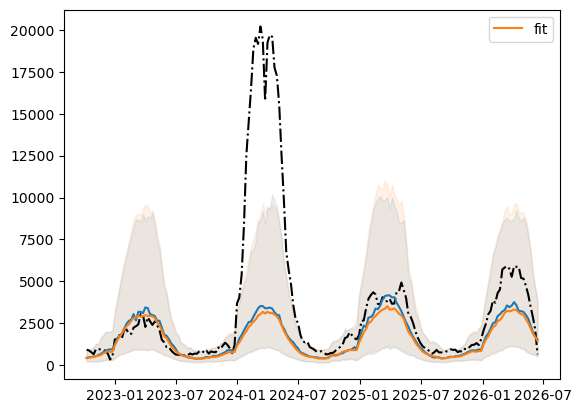

In [6]:
_,ax = plt.subplots()

ax.plot(df_ens.date, df_ens.casos, color = 'black', linestyle = '-.')

ax.plot(df_ens.date, df_ens.pred, color = 'tab:blue')

ax.fill_between(df_ens.date, df_ens.lower_90, df_ens.upper_90, color = 'tab:blue', alpha = 0.1)

ax.plot(df_ens.date, df_ens.fit_median, label = 'fit', color = 'tab:orange')

ax.fill_between(df_ens.date, df_ens.fit_lower_90, df_ens.fit_upper_90,color = 'tab:orange', alpha = 0.1)

ax.legend()

plt.show()

## Organizando os dados:

In [7]:
from epiweeks import Week

In [8]:
def transform_epiweek_label(ep_label):
  '''
  Function to change the epiweeks 41-40 into 1-52.
  '''
  year_ep_label = int(ep_label[:4])
  week_ep_label = int(ep_label[4:])

  if week_ep_label <=40:
    new_week = 12 + week_ep_label
    new_year = year_ep_label

  else:
    new_week = week_ep_label - 40
    new_year = year_ep_label +1

  if new_week <=9:
    week_str = f'0{new_week}'
  else:
    week_str = str(new_week)

  new_ep_label = f'{new_year}{week_str}'

  return new_ep_label

def add_epiweek_label(df_w, date_col = 'date'):
    '''
    This function assumes that the dataframe has a datetime index
    and add the epiweek and year value
    '''

    df_w['epiweek_label'] = [Week.fromdate(x) for x in df_w[date_col]]

    df_w['epiweek_label'] = df_w['epiweek_label'].astype(str)

    df_w = df_w.loc[df_w.epiweek_label.str[-2:].astype(int) != 53]

    df_w['epiweek_label'] = df_w['epiweek_label'].apply(transform_epiweek_label)

    df_w['epiweek'] = df_w['epiweek_label'].astype(str).str[-2:].astype(int)
    df_w['year'] = df_w['epiweek_label'].astype(str).str[:4].astype(int)

    return df_w

Calculo do PIT: 

Dado o modelo Log-Normal com parâmetros μ e σ, qual é a probabilidade de observar um número de casos menor ou igual ao número observado?

In [9]:
df = df_ens.copy()

df["pit"] = lognorm.cdf(
    df["casos"],
    s=df["sigma"],
    scale=np.exp(df["mu"])
)

df = add_epiweek_label(df)


df.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,...,sigma,fit_median,fit_upper_90,fit_lower_90,adm_1,casos,pit,epiweek_label,epiweek,year
0,2022-10-09,174.147658,219.780460,237.439152,340.00,418.000000,580.235367,770.100000,856.000000,934.000000,...,0.427836,425.934592,860.930852,210.725723,52,921,0.964266,202301,1,2023
1,2022-10-16,169.055588,230.900000,257.500000,342.00,464.000000,646.295348,817.371885,919.681468,1034.213726,...,0.447268,452.882893,945.131277,217.009975,52,867,0.926741,202302,2,2023
2,2022-10-23,174.147658,198.784126,235.747357,344.00,477.980955,685.554314,886.286500,940.628800,1167.536634,...,0.488657,458.496004,1024.255425,205.240393,52,763,0.851354,202303,3,2023
3,2022-10-30,184.865188,227.750000,271.000000,355.00,502.845671,692.873260,937.491756,1060.651303,1360.465315,...,0.490727,498.734824,1117.946483,222.494036,52,650,0.705335,202304,4,2023
4,2022-11-06,198.750000,230.000000,272.000000,368.75,528.500000,666.000000,1138.000000,1272.907400,1585.035397,...,0.527326,536.871502,1278.103561,225.514597,52,951,0.860874,202305,5,2023


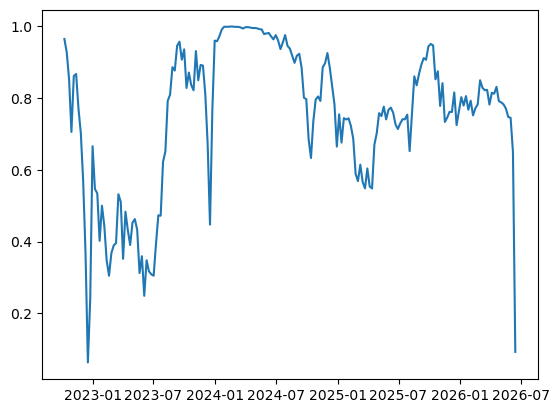

In [10]:
_,ax = plt.subplots()

ax.plot(df.date, df.pit)

## Recalibração

G define a recalibracão, tal que a CDF F* recalibrada é: 

F*(y) = G(F(y))

Método não paramétrico: 

In [11]:
from scipy.stats import norm
from scipy.interpolate import PchipInterpolator

In [12]:
class NonparametricRecalibrator:
    
    def __init__(self):
        self.spline = None
        self.inverse_spline = None
        self.pit_sorted = None
        self.ecdf = None

    def fit(self, y, mu, sigma):

        y = np.asarray(y)
        mu = np.asarray(mu)
        sigma = np.asarray(sigma)

        # PIT
        pit = lognorm.cdf(
            y,
            s=sigma,
            scale=np.exp(mu)
        )

        mask = np.isfinite(pit)
        pit = pit[mask]

        pit_sorted = np.sort(pit)

        n = len(pit_sorted)

        # ECDF
        ecdf = np.arange(1, n + 1) / n

        # Evitar problemas nas extremidades
        eps = 1e-6

        pit_sorted = np.clip(
            pit_sorted,
            eps,
            1 - eps
        )

        ecdf = np.clip(
            ecdf,
            eps,
            1 - eps
        )

        # G(u)
        self.spline = PchipInterpolator(
            pit_sorted,
            ecdf
        )

        # G^{-1}(p)
        self.inverse_spline = PchipInterpolator(
            ecdf,
            pit_sorted
        )

        self.pit_sorted = pit_sorted
        self.ecdf = ecdf

        return self

    def transform_cdf(self, cdf):

        cdf = np.asarray(cdf)

        cdf = np.clip(
            cdf,
            self.pit_sorted[0],
            self.pit_sorted[-1]
        )

        return self.spline(cdf)

    def ppf(self, p, mu, sigma):

        p = np.asarray(p)

        # G^{-1}(p)
        q = self.inverse_spline(
            np.clip(
                p,
                self.ecdf[0],
                self.ecdf[-1]
            )
        )

        # F_LN^{-1}(q)
        return np.exp(
            mu + sigma * norm.ppf(q)
        )

## Aplicar para todos as semanas: 

In [16]:
test_year = 2026
levels = np.array([
    0.025,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.975
])


df_recal_end = pd.DataFrame()

for week in np.arange(1, 37): 

    df_calibration = df.loc[(df.year < test_year) & (df.epiweek < week + 5) & (df.epiweek > week - 5)]


    df_forecast = df.loc[(df.year == test_year) & (df.epiweek ==  week)]

    recalibrator = NonparametricRecalibrator()

    recalibrator.fit(
            y=df_calibration["casos"],
            mu=df_calibration["mu"],
            sigma=df_calibration["sigma"]
        )


    quantiles = np.column_stack([
    recalibrator.ppf(
        p,
        mu=df_forecast["mu"].values,
        sigma=df_forecast["sigma"].values
    )
        for p in levels
    ])

    df_recal = pd.DataFrame(quantiles, columns = [ 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
        'upper_50', 'upper_80', 'upper_90', 'upper_95'])

    df_recal['date'] = df_forecast.date.values[0]

    df_recal_end = pd.concat([df_recal_end, df_recal], ignore_index = True)

df_recal_end.head()

,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,date
0,546.449808,546.449808,564.317474,604.349699,686.962745,730.528071,842.886138,857.213785,893.233010,2025-10-05
1,555.532393,555.532393,583.184406,648.237321,705.700695,749.818979,864.402087,873.902301,909.773860,2025-10-12
2,585.594329,587.657025,620.984922,690.408226,746.142426,795.136942,900.179612,912.700309,944.550399,2025-10-19
3,590.461826,599.643235,634.087081,699.500465,774.422073,851.921400,917.746210,954.694743,984.294456,2025-10-26
4,610.710117,627.130739,688.138175,769.911759,855.410486,952.109243,1051.761817,1061.021357,1088.351912,2025-11-02


Comp ensembles:

In [17]:
df_default = df.loc[df.year == test_year]

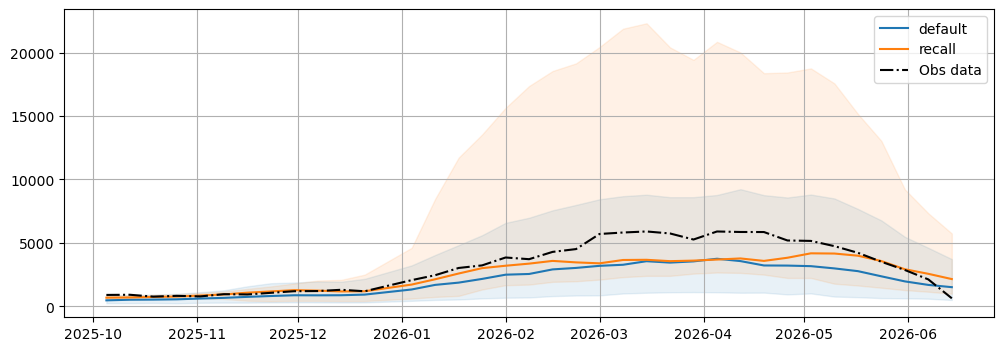

In [18]:
_,ax = plt.subplots(figsize = (12, 4))

ax.plot(df_default.date, df_default.pred, color = 'tab:blue', label = 'default')

ax.fill_between(df_default.date, df_default.lower_90, df_default.upper_90, color = 'tab:blue', alpha = 0.1)

ax.plot(df_recal_end.date, df_recal_end.pred, color = 'tab:orange', label = 'recall')

ax.fill_between(df_recal_end.date, df_recal_end.lower_90, df_recal_end.upper_90, color = 'tab:orange', alpha = 0.1)

ax.plot(df_default.date, df_default.casos, color = 'black', linestyle = '-.', label = 'Obs data')

ax.legend()
ax.grid()
plt.show()
